<b style="font-size:32px; color:navy">Szeregi czasowe - przykłady</b>

Szereg czasowy – realizacja procesu stochastycznego, którego dziedziną jest czas; to ciąg informacji uporządkowanych w czasie, których pomiary wykonywane są z dokładnym krokiem czasowym. Jeżeli krok nie będzie regularny wtedy mamy do czynienia z szeregiem czasowym rozmytym. [Wikipedia]

# Pandas - podstawy

Więcej na:
* https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html

In [16]:
import pandas as pd
import numpy as np
%matplotlib inline

df = pd.read_csv('.\dane\Production.csv')

In [17]:
len(df)

500

In [18]:
df.head()

,weekday,produced,defective
0,Monday,73,7
1,Tuesday,75,10
2,Wednesday,86,7
3,Thursday,64,7
4,Friday,70,6


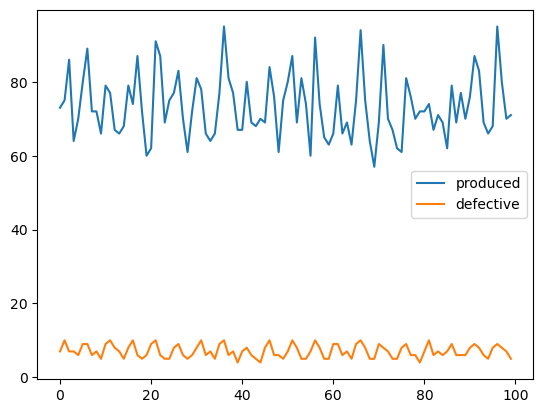

In [19]:
df[:100].plot();

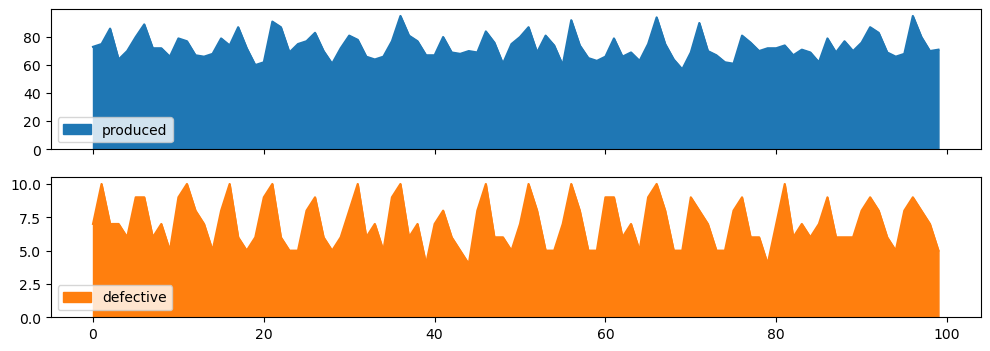

In [20]:
axs = df[:100].plot.area(figsize=(12, 4), subplots=True)

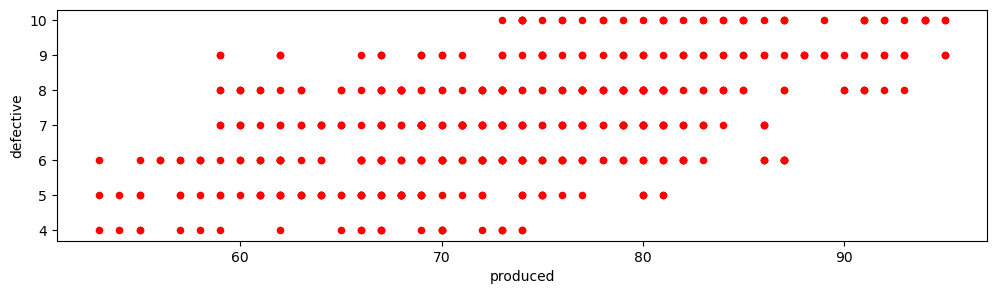

In [21]:
df.plot.scatter(x='produced',y='defective',color='red',s=20,figsize=(12,3));

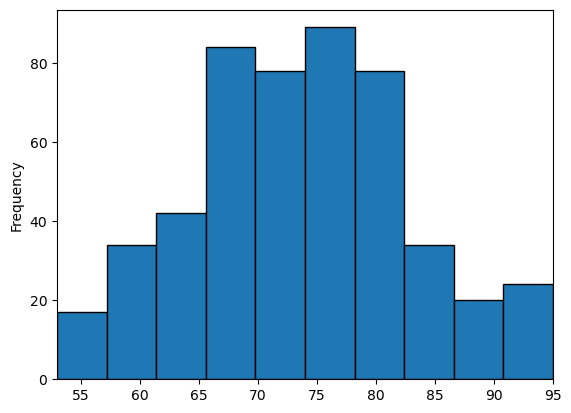

In [22]:
df['produced'].plot.hist(edgecolor='k').autoscale(axis='x',tight=True);

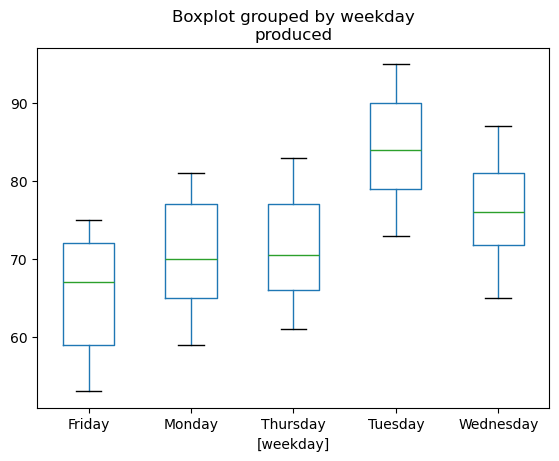

In [23]:
df[['produced','weekday']].boxplot(by='weekday',grid=False);

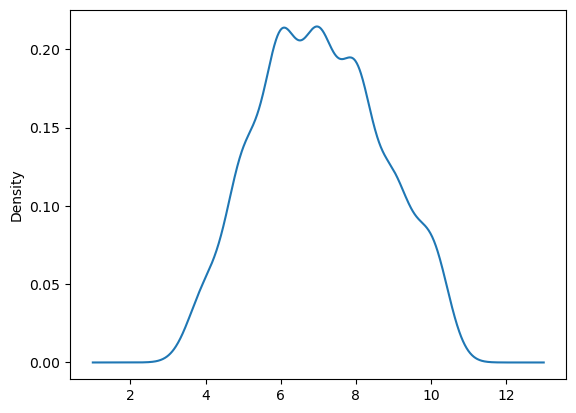

In [24]:
df['defective'].plot.kde();

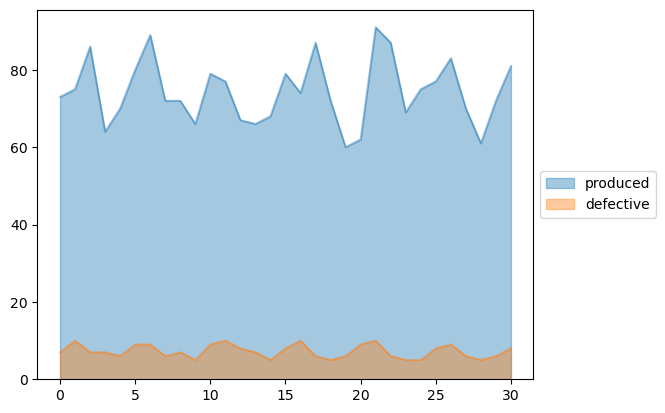

In [25]:
ax = df.loc[0:30].plot.area(stacked=False,alpha=0.4)
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5));

# Podstawy - szeregi czasowe

In [11]:
df = pd.read_csv('./Dane/monthly_milk_production.csv', encoding='utf8',sep=';')
title = "Miesięczna produkcja mleka: litry na krowę. Styczeń '62 - grudzień '75"

In [12]:
len(df)

168

In [13]:
df.head()

,Date,Production
0,1962-01,267
1,1962-02,254
2,1962-03,290
3,1962-04,298
4,1962-05,330


In [14]:
df.dtypes

Date          object
Production     int64
dtype: object

In [15]:
# Zmieniamy format na datę:
df['Date']=pd.to_datetime(df['Date'])
df.dtypes

Date          datetime64[ns]
Production             int64
dtype: object

In [16]:
# Ustawiamy index na datę:
df.set_index('Date',inplace=True)
df.head()

,Production
Date,
1962-01-01,267
1962-02-01,254
1962-03-01,290
1962-04-01,298
1962-05-01,330


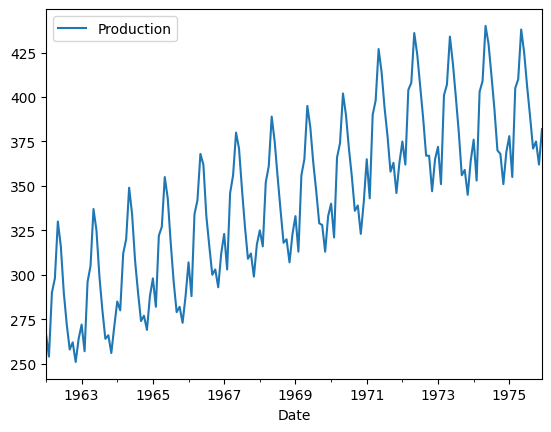

In [17]:
df.plot();

In [18]:
# Dodajemy kolumne związaną z miesiącami:
df['Month']=df.index.month
df.head()

,Production,Month
Date,,
1962-01-01,267,1
1962-02-01,254,2
1962-03-01,290,3
1962-04-01,298,4
1962-05-01,330,5


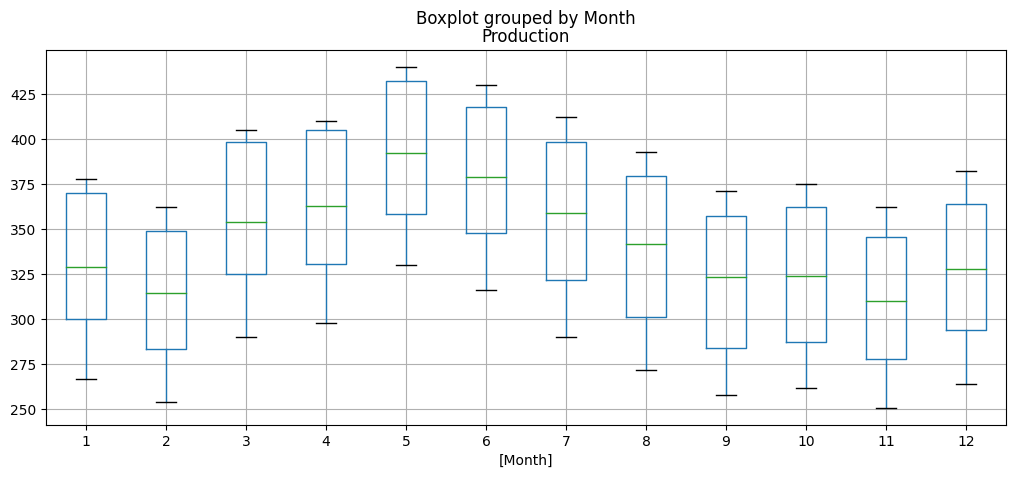

In [19]:
df.boxplot(by='Month',figsize=(12,5));

In [20]:
# Trochę formatowania, tylko na wykresie trzeba lepiej zadbać o kolejność (tu będzie alfabetyczna),
# można użyć też seaborn, tam jest bezpośrednio orderw boxplot
df['Month']=df.index.strftime('%B')
df.head()

,Production,Month
Date,,
1962-01-01,267,January
1962-02-01,254,February
1962-03-01,290,March
1962-04-01,298,April
1962-05-01,330,May


# Szeregi czasowe - statsmodels

W tym zadaniu wykorzystano dane z Bazy Ekonomicznej Rezerwy Federalnej (FRED) dotyczące indeksu produkcji przemysłowej dla elektryczności i gazu od stycznia 1970 do listopada 2020.

Źródło: https://fred.stlouisfed.org/series/IPG2211A2N

In [21]:
df = pd.read_csv('./Dane/Energy_production.csv',index_col=0,parse_dates=True)
df.head()

,EnergyIndex
DATE,
1939-01-01,3.3842
1939-02-01,3.4100
1939-03-01,3.4875
1939-04-01,3.5133
1939-05-01,3.5133


In [22]:
df.index

DatetimeIndex(['1939-01-01', '1939-02-01', '1939-03-01', '1939-04-01',
               '1939-05-01', '1939-06-01', '1939-07-01', '1939-08-01',
               '1939-09-01', '1939-10-01',
               ...
               '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01',
               '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01',
               '2020-10-01', '2020-11-01'],
              dtype='datetime64[ns]', name='DATE', length=983, freq=None)

In [23]:
#Przypisz częstotliwość MS do indeksu
df.index.freq = 'MS'
df.index

DatetimeIndex(['1939-01-01', '1939-02-01', '1939-03-01', '1939-04-01',
               '1939-05-01', '1939-06-01', '1939-07-01', '1939-08-01',
               '1939-09-01', '1939-10-01',
               ...
               '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01',
               '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01',
               '2020-10-01', '2020-11-01'],
              dtype='datetime64[ns]', name='DATE', length=983, freq='MS')

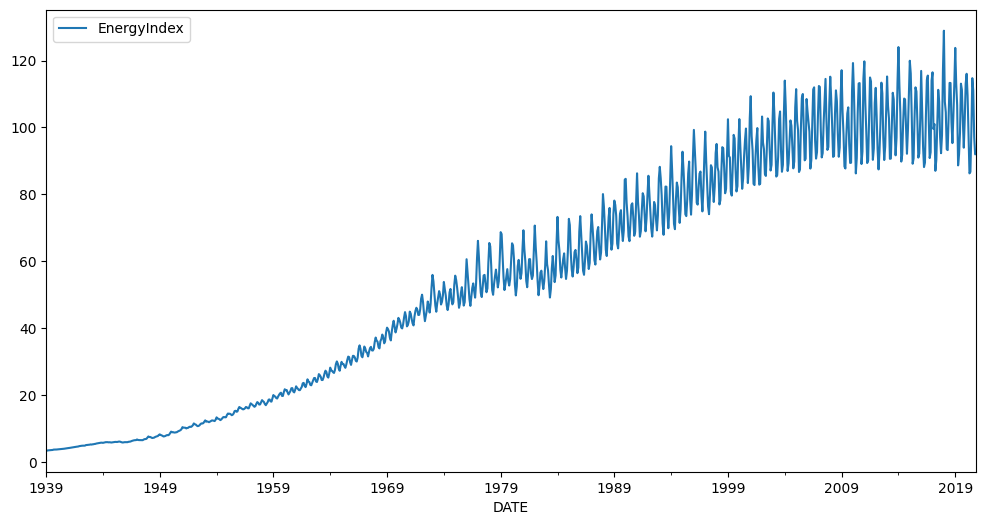

In [24]:
df.plot(figsize=(12,6)).autoscale(axis='x',tight=True);

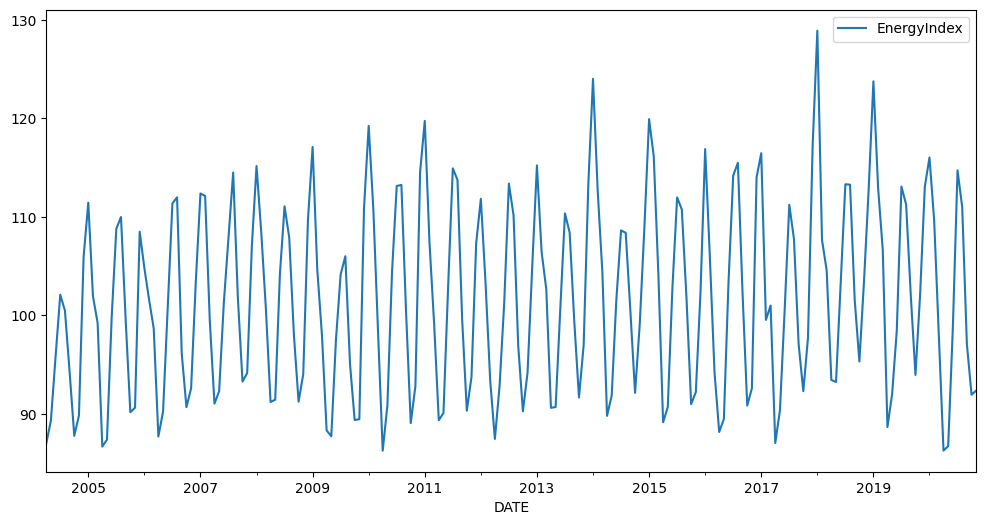

In [25]:
df[-200:].plot(figsize=(12,6)).autoscale(axis='x',tight=True);

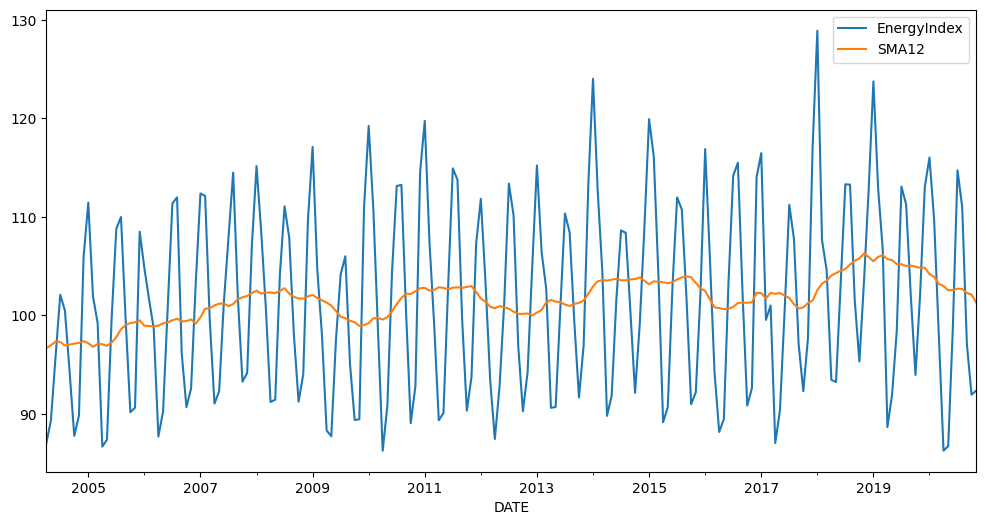

In [26]:
# Dodajemy kolumnę przedstawiającą 12-miesięczną prostą średnią ruchomą (SMA).
df['SMA12'] = df['EnergyIndex'].rolling(window=12).mean()
df[-200:].plot(figsize=(12,6)).autoscale(axis='x',tight=True);

In [27]:
import warnings
warnings.simplefilter(action='ignore')

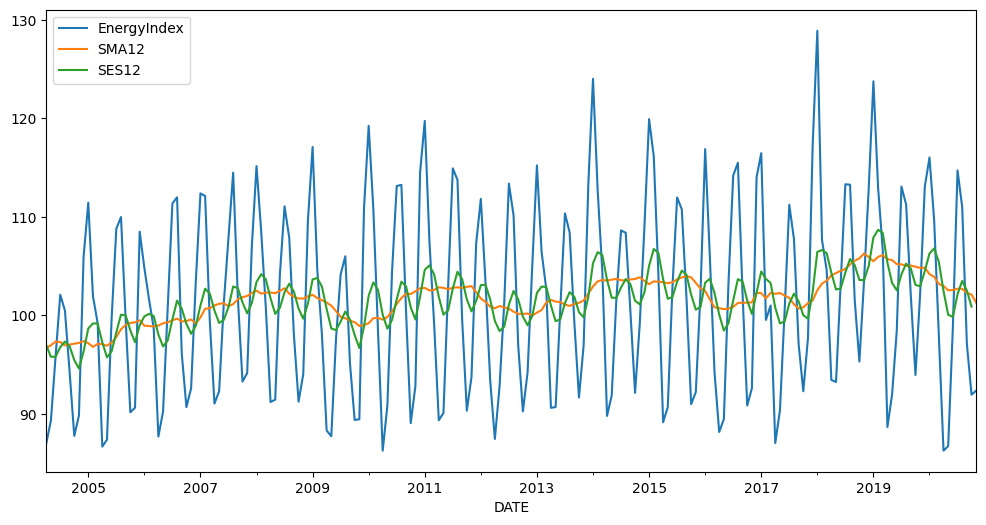

In [28]:
#Dodajemy kolumnę, która pokazuje wykładniczą ważoną średnią ruchomą (EWMA) o rozpiętości 12, 
#używając funkcji statsmodels SimpleExpSmoothing.

# conda install -c conda-forge statsmodels

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

df['SES12']=SimpleExpSmoothing(df['EnergyIndex']).fit(smoothing_level=2/(12+1),optimized=False).fittedvalues.shift(-1)
df[-200:].plot(figsize=(12,6)).autoscale(axis='x',tight=True);

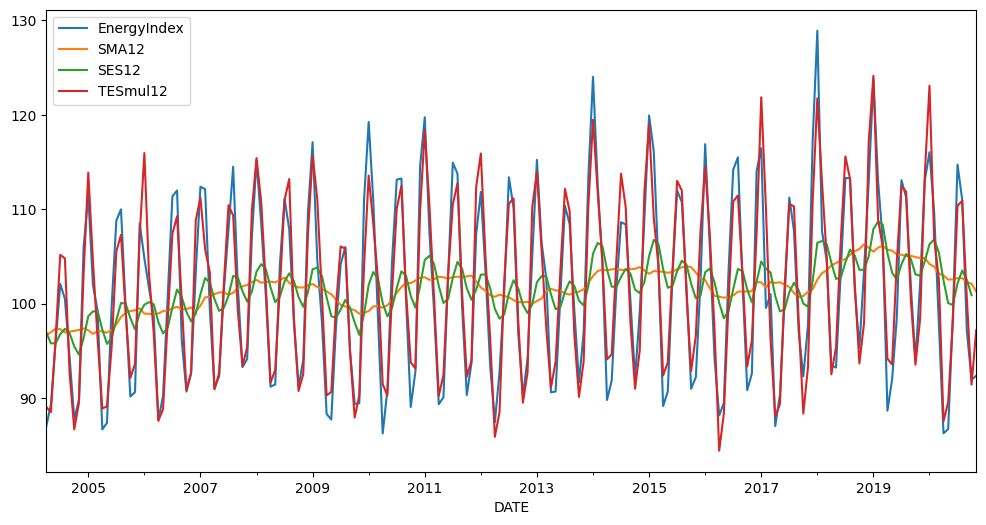

In [29]:
#Dodajemy kolumnę, która pokazuje dopasowany model Holta-Wintersa przy użyciu potrójnego wygładzania wykładniczego
#z modelami multiplikatywnymi.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df['TESmul12'] = ExponentialSmoothing(df['EnergyIndex'],trend='mul',
                                      seasonal='mul',seasonal_periods=12).fit().fittedvalues.shift(0)
df[-200:].plot(figsize=(12,6)).autoscale(axis='x',tight=True);

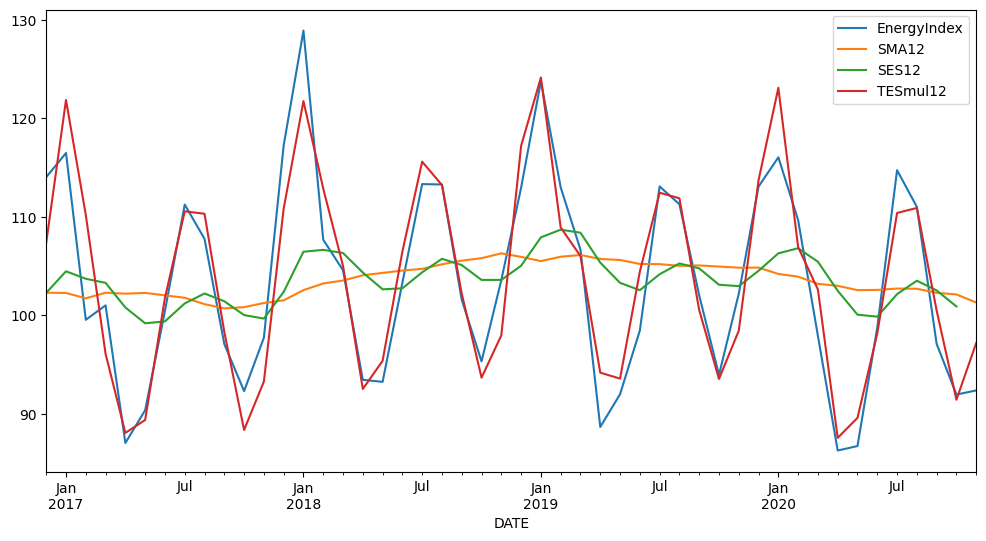

In [30]:
# 4 lata:
df.iloc[-48:].plot(figsize=(12,6)).autoscale(axis='x',tight=True);

# Prognozowanie

In [3]:
# Ponawiam wszystko, aby w punkcie były wszystkie elementy 
import pandas as pd
import numpy as np
%matplotlib inline

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose      # dekompozycja
from pmdarima import auto_arima                              
# pip install pmdarima

from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('./Dane/HospitalityEmployees.csv',index_col='Date',parse_dates=True)
df.index.freq = 'MS'
print(len(df))
print(df.head())

348
            Employees
Date                 
1990-01-01     1064.5
1990-02-01     1074.5
1990-03-01     1090.0
1990-04-01     1097.4
1990-05-01     1108.7


Dane przedstawiają liczbę pracowników w tysiącach osób jako średnią miesięczną od stycznia 1990 do grudnia 2018.

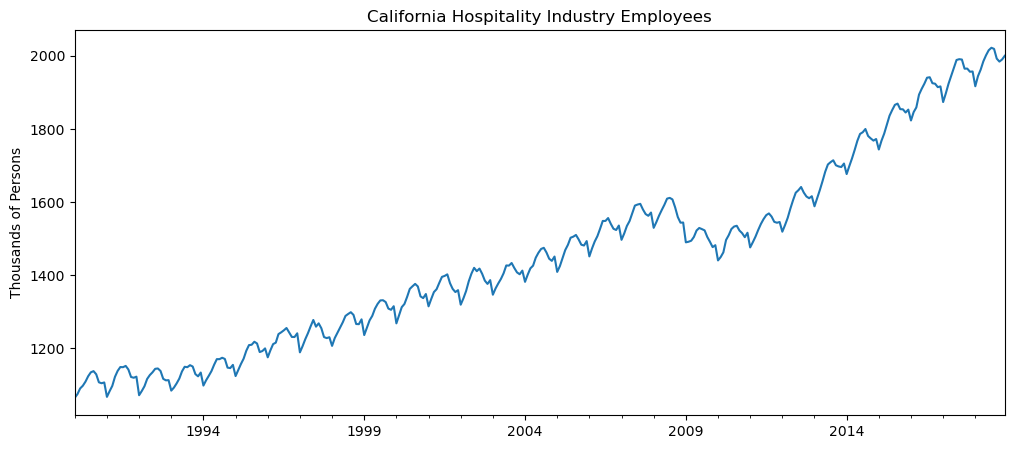

In [5]:
title='California Hospitality Industry Employees'
ylabel='Thousands of Persons'
xlabel=''

ax = df['Employees'].plot(figsize=(12,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);

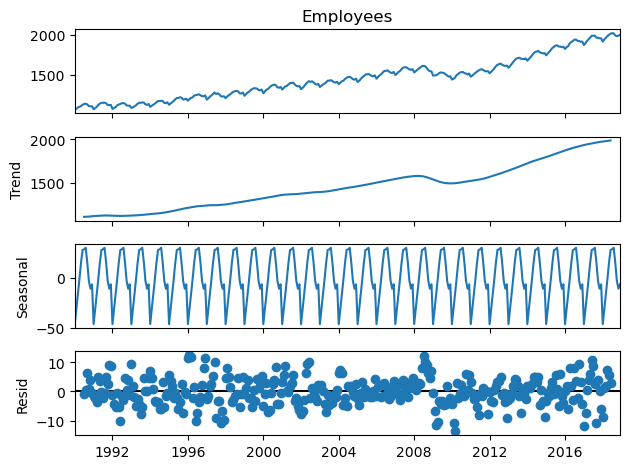

In [6]:
#Dekompozycja szeregu czasowego
result = seasonal_decompose(df['Employees'], model='add')
result.plot();

Jak widać, mamy wyraźną sezonowość oraz trend rosnący.

Modele (S)ARIMA należą do najczęściej stosowanych i najskuteczniejszych metod prognozowania szeregów czasowych. Potrafią one uwzględnić wiele różnych struktur niedających się zaobserwować podczas zwykłej wizualnej analizy. W szczególności możemy wykryć istniejące trendy oraz wahania sezonowe. Konstrukcja tej klasy modeli polega na stopniowym uogólnianiu prostych metod autoregresji i ruchomej średniej.

W modelu ARIMA tym wyróżnia się trzy parametry: parametr autoregresyjny (p), rząd różnicowania (d), parametr średniej ruchomej (q).
Model ARIMA (p, q, d), opisywany jest również za pomocą cyfr np. (0, 1, 1), gdzie 0 oznacza zerową ilość parametrów autoregresyjnych, 1-jednokrotne różnicowanie dla 1-jednego parametru średniej ruchomej.
Model SARIMA(p, d, q)(P, D, Q): model ARIMA, który uwzględnia składową sezonowości (P – rząd opóźnień sezonowych typu AR, Q – rząd opóźnień sezonowych typu MA, D – różnicowanie składowej sezonowej).

In [7]:
# Podsumowanie 
# Proces auto-ARIMA ma na celu zidentyfikowanie najbardziej optymalnych parametrów dla modelu ARIMA, 
# opierając się na jednym dopasowanym modelu ARIMA.
auto_arima(df['Employees'],seasonal=True,m=12).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  348
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1098.252
Date:                              Fri, 30 May 2025   AIC                           2208.504
Time:                                      06:40:48   BIC                           2231.600
Sample:                                  01-01-1990   HQIC                          2217.700
                                       - 12-01-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9243      0.045     20.535      0.000       0.836       1.012
ma.L1         -0.9439      0.070    -13.494      0.000      -1.081      -0.807
ma.L2          0.1288      0.060      2.140      0.032       0.011       0.247
ar.S.L12       0.9972      0.001    705.793      0.000       0.994       1.000
ma.S.L12      -0.7492      0.043    -17.342      0.000      -0.834      -0.665
sigma2        29.2941      1.717     17.063      0.000      25.929      32.659
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.37
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                            -0.11
Prob(H) (two-sided):                  0.40   Kurtosis:                         5.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
# Podział
train = df.iloc[:len(df)-12]
test = df.iloc[len(df)-12:]

In [9]:
# Standardowy model
model = SARIMAX(train['Employees'],order=(0,1,0),seasonal_order=(1,0,0,12))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          Employees   No. Observations:                  336
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood               -1127.513
Date:                            Fri, 30 May 2025   AIC                           2259.027
Time:                                    06:40:48   BIC                           2266.655
Sample:                                01-01-1990   HQIC                          2262.068
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.9256      0.015     62.220      0.000       0.896       0.955
sigma2        45.7722      2.399     19.081      0.000      41.071      50.474
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                82.26
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               0.78   Skew:                            -0.18
Prob(H) (two-sided):                  0.19   Kurtosis:                         5.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [10]:
# Uzyskaj przewidywane wartości
start=len(train)
end=len(train)+len(test)-1
predictions = results.predict(start=start, 
                              end=end, dynamic=False, typ='levels').rename('SARIMA(0,1,0)(2,0,0,12) Predictions')

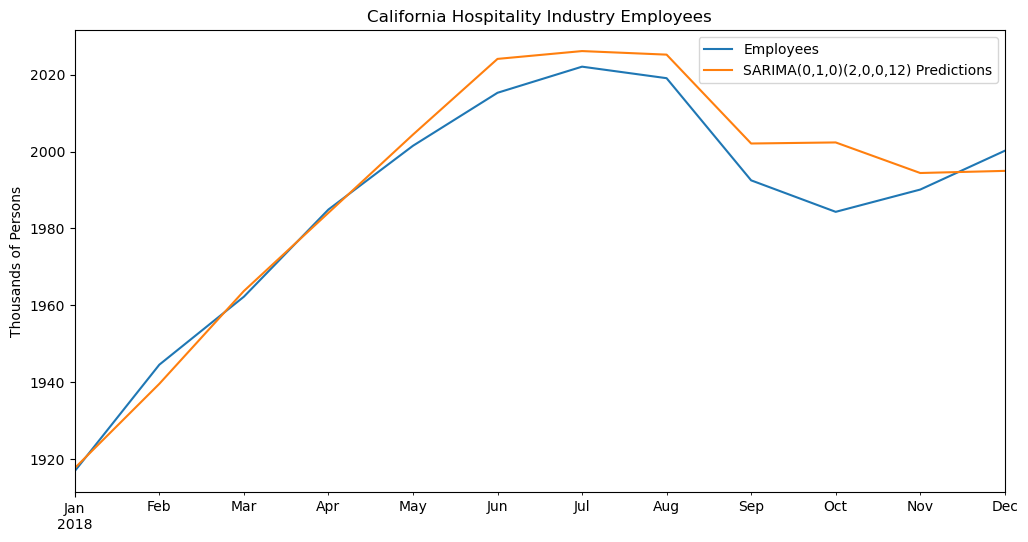

In [11]:
title='California Hospitality Industry Employees'
ylabel='Thousands of Persons'
xlabel=''

ax = test['Employees'].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);

In [12]:
error1 = mean_squared_error(test['Employees'], predictions)
error2 = rmse(test['Employees'], predictions)
print(f'SARIMA(0,1,0)(2,0,0,12) MSE Error: {error1:11.10}')
print(f'SARIMA(0,1,0)(2,0,0,12) RMSE Error: {error2:11.10}')

SARIMA(0,1,0)(2,0,0,12) MSE Error: 52.76967128
SARIMA(0,1,0)(2,0,0,12) RMSE Error: 7.264273624


In [13]:
#Przetrenuj ponownie model na pełnych danych i prognozuj rok w przyszłość.
model = SARIMAX(df['Employees'],order=(0,1,0),seasonal_order=(2,0,0,12))
results = model.fit()
fcast = results.predict(len(df),len(df)+11,typ='levels').rename('SARIMA(0,1,0)(2,0,0,12) Forecast')

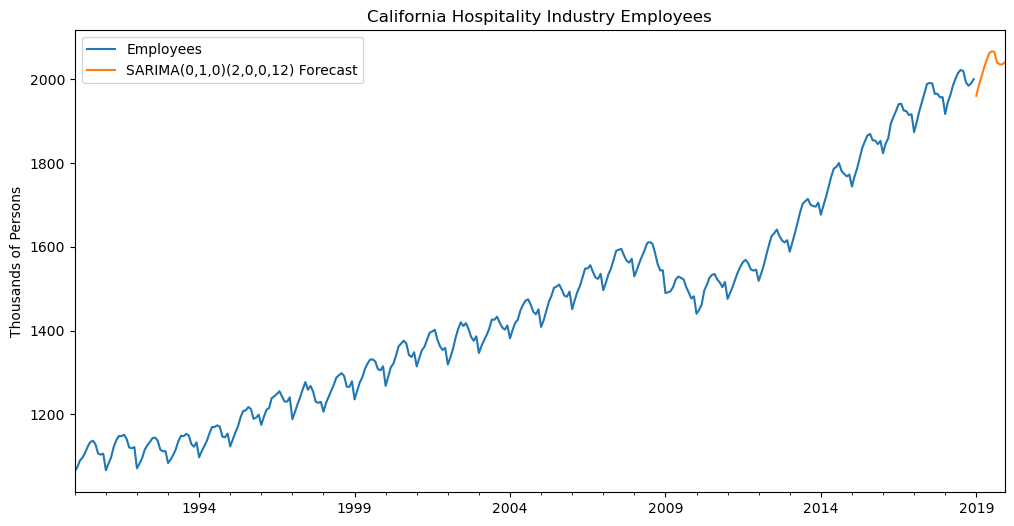

In [14]:
title='California Hospitality Industry Employees'
ylabel='Thousands of Persons'
xlabel=''

ax = df['Employees'].plot(legend=True,figsize=(12,6),title=title)
fcast.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);

Więcej na temat szeregów czasowych można znaleźć pod adresem:

* https://pbiecek.github.io/NaPrzelajDataMiningR/part-7.html

Dla R, ale teoria dobrze opisana.
        